In [1]:
import numpy as np
import polars as pl
import pandas as pd
import tensorflow as tf
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from working_data import clean_cols, clean_non_minute_rows, alt_label_df as label_df, normalize_by_window, split_df, chunky_split_df, add_rsi, add_hour_position
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from model_builder_trans import combined_loss
from scipy.signal import savgol_filter

2025-06-05 01:45:45.796288: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-05 01:45:45.908615: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-06-05 01:45:46.781950: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2025-06-05 01:45:48.353263: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-06-05 01:45:48.579647: 

In [2]:
NORMALIZING_WINDOW_SIZE = 6*24
LABELING_WINDOW_SIZE = 24
POSITIVE_SLOPE = 0.3
LABEL_CUR_CANDLE_MULTIPLIER = 0
LABEL_MEAN_MULTIPLIER = 8
BATCH_SIZE = 256
NUM_TOKENS = 64
OTHER_TOKENS = 64
LOOKBACK_WINDOW = NUM_TOKENS + 1
D_MODEL = 512
FF_DIM = D_MODEL*2
NUM_HEADS = D_MODEL//24

In [3]:
source_csv = "olderdata/GBPUSD/five_minutes.csv"
source_2_csv = "olderdata/GBPUSD/hours.csv"
working_path = "working"

In [4]:
df = pd.read_csv(source_csv)
df = clean_cols(df)
df = add_rsi(df)
df = add_hour_position(df)
df = normalize_by_window(
    df, 
    window_size=NORMALIZING_WINDOW_SIZE, 
    normalizing_cols=[
        'open',
        'high',
        'low',
        'close',
    ])
print("labeling")
df = label_df(df, window_size=LABELING_WINDOW_SIZE, mean_multiplier=LABEL_MEAN_MULTIPLIER, cur_candle_multiplier=LABEL_CUR_CANDLE_MULTIPLIER)
print(df['target'].value_counts())
split_df(
    df=df, 
    dump_path=working_path,
    lookback=LOOKBACK_WINDOW,
    cols=[
        'time',
        'datetime',
        'hour_position',
        'hour_position_sin',
        'hour_position_cos',
        'open',
        'high',
        'low',
        'close',
        'open_normalized',
        'high_normalized',
        'low_normalized',
        'close_normalized',
        'rsi',
        'target'
    ])

df_alt = pd.read_csv(source_2_csv)
df_alt = add_rsi(df_alt)
df_alt = clean_cols(df_alt)
df_alt = normalize_by_window(
    df_alt, 
    window_size=NORMALIZING_WINDOW_SIZE, 
    normalizing_cols=[
        'open',
        'high',
        'low',
        'close',
    ])

df_alt.to_csv(os.path.join(working_path, 'larger_frame.csv'), index=False)

              time     open     high      low    close       rsi
300977  1736887800  1.22048  1.22050  1.22020  1.22043  0.665649
300978  1736888100  1.22044  1.22071  1.22040  1.22052  0.672951
300979  1736888400  1.22052  1.22061  1.22031  1.22041  0.654149
300980  1736888700  1.22038  1.22089  1.22035  1.22062  0.672936
300981  1736889000  1.22061  1.22063  1.22028  1.22047  0.645944
labeling
target
0    293987
1      6839
Name: count, dtype: int64
             time     open     high      low    close  tick_volume  spread  \
25080  1736874000  1.21549  1.22012  1.21548  1.21992         7477      18   
25081  1736877600  1.21989  1.22114  1.21756  1.21840         6962      18   
25082  1736881200  1.21840  1.21856  1.21669  1.21843         5216      18   
25083  1736884800  1.21843  1.22078  1.21824  1.22052         3260      18   
25084  1736888400  1.22052  1.22096  1.21947  1.21985         2798      19   

       real_volume       rsi  
25080            0  0.538425  
25081        

In [5]:
def prepare_data(file_path, file_path_2, num_tokens, other_tokens, window_size=1440, batch_size=32, smote=False, shuffle=False, cols=['open', 'high', 'low', 'close']):
    emd_range = window_size
    # Load CSV lazily with Polars
    collect_cols = cols + ['time', 'target']
    other_cols = cols + ['time']
    df_lazy = pl.scan_csv(file_path).select(collect_cols)
    df_other = pl.scan_csv(file_path_2).select(other_cols)
    
    # Collect the dataframes
    df_collected = df_lazy.collect()
    df_other_collected = df_other.collect()
    
    # Safety mechanism: get the other_tokens-th time value from df_other_collected
    if df_other_collected.shape[0] >= other_tokens + 1:  # +1 because we'll skip the most recent one
        min_time_threshold = df_other_collected[other_tokens, 'time']  # use other_tokens instead of other_tokens-1
        # Filter df_collected to only include rows with time >= min_time_threshold
        df_collected = df_collected.filter(pl.col('time') >= min_time_threshold)
    
    total_rows = df_collected.shape[0]
    
    # For SMOTE handling
    indices_target_0 = []
    indices_target_1 = []
    
    if smote:
        df_collected = df_collected.with_columns(pl.arange(0, total_rows).alias("index"))
        indices_target_1 = df_collected.filter(
            (pl.col("target") == 1) & (pl.col("index") >= emd_range)
        ).select("index").to_series().to_list()

        # Get indices where target is 0 and >= num_tokens
        indices_target_0 = df_collected.filter(
            (pl.col("target") == 0) & (pl.col("index") >= emd_range)
        ).select("index").to_series().to_list()

        df_collected = df_collected.drop('index')
    
    # Extract time arrays once for binary search
    other_time_array = df_other_collected['time'].to_numpy()
    
    while True:  # Loop to reshuffle and restart at each epoch
        # Create an array of indices to use for shuffling
        indices = list(range(emd_range, total_rows))
        if smote:
            indices_target_1_complete = []
            while len(indices_target_1_complete) < len(indices_target_0):
                indices_target_1_complete += indices_target_1

            indices_target_1_complete = indices_target_1_complete[:len(indices_target_0)]

            indices = indices_target_0 + indices_target_1_complete

        # Shuffle indices if required
        if shuffle:
            np.random.shuffle(indices)

        input_list = []
        input_other_list = []  # New list for the second input tensor
        target_list = []

        for idx in indices:
            # Create imfs
            signal = np.array(df_collected[cols][idx - emd_range + 1:idx + 1])
            signal_time_index = df_collected[idx, 'time']

            # Use binary search to find the position in other_time_array
            # where time <= signal_time_index
            pos = np.searchsorted(other_time_array, signal_time_index, side='right') - 1
            
            # Ensure we have enough data (other_tokens+1 rows before current position)
            if pos >= other_tokens:
                # Get the previous other_tokens rows (and skip the current one)
                signal_other = np.array(df_other_collected[pos-other_tokens:pos, cols])
                
                # Fetch the previous `num_tokens` rows for the input based on the current index
                input_rows = signal[-num_tokens:]
                input_rows_other = signal_other
                
                target_value = df_collected[idx, -1]  # Get 'target' for the target

                # Append to input lists
                input_list.append(input_rows)
                input_other_list.append(input_rows_other)
                target_list.append(target_value)

                # Yield once we have enough for a batch
                if len(input_list) == batch_size:
                    # Convert lists to NumPy arrays
                    input_array = np.array(input_list)
                    input_other_array = np.array(input_other_list)
                    target_array = np.array(target_list)

                    # Convert NumPy arrays to TensorFlow tensors
                    input_tensor = tf.convert_to_tensor(input_array, dtype=tf.float32)
                    input_other_tensor = tf.convert_to_tensor(input_other_array, dtype=tf.float32)
                    target_tensor = tf.convert_to_tensor(target_array, dtype=tf.int32)

                    yield input_tensor, input_other_tensor, target_tensor

                    # Reset lists for the next batch
                    input_list.clear()
                    input_other_list.clear()
                    target_list.clear()

        # If there are remaining samples that didn't make a full batch
        if input_list:
            input_array = np.array(input_list)
            input_other_array = np.array(input_other_list)
            target_array = np.array(target_list)

            input_tensor = tf.convert_to_tensor(input_array, dtype=tf.float32)
            input_other_tensor = tf.convert_to_tensor(input_other_array, dtype=tf.float32)
            target_tensor = tf.convert_to_tensor(target_array, dtype=tf.int32)

            yield input_tensor, input_other_tensor, target_tensor
            
        break

In [6]:
def create_dataset_generator(file_path, file_path_2, batch_size, num_tokens, other_tokens, window_size=LOOKBACK_WINDOW, shuffle=False, repeat=False, smote=False, cols=['open', 'high', 'low', 'close']):
    dataset = tf.data.Dataset.from_generator(
        lambda: prepare_data(file_path, file_path_2, window_size=window_size, batch_size=batch_size, 
                            num_tokens=num_tokens, other_tokens=other_tokens, shuffle=shuffle, 
                            smote=smote, cols=cols),
        output_signature=(
            tf.TensorSpec(shape=(None, num_tokens, len(cols)), dtype=tf.float32),
            tf.TensorSpec(shape=(None, other_tokens, len(cols)), dtype=tf.float32),
            tf.TensorSpec(shape=(None,), dtype=tf.int32)
        )
    )

    dataset = dataset.map(lambda x, y, z: ((x, y), z))

    if repeat:
        dataset = dataset.repeat()
    return dataset


def get_total_rows(file_path, file_path_2, num_tokens, other_tokens, window_size=LOOKBACK_WINDOW, smote=False):
    # Load the main dataset
    df_lazy = pl.scan_csv(file_path)
    df_collected = df_lazy.collect()
    
    # Load the other dataset
    df_other = pl.scan_csv(file_path_2)
    df_other_collected = df_other.collect()
    
    # Safety mechanism: filter out rows from df_collected with time less than other_tokens+1 row in df_other
    if df_other_collected.shape[0] >= other_tokens + 1:
        min_time_threshold = df_other_collected[other_tokens, 'time']
        df_collected = df_collected.filter(pl.col('time') >= min_time_threshold)
    
    total_rows = df_collected.shape[0]
    
    if not smote:
        return total_rows
    
    df_collected = df_collected.with_columns(pl.arange(0, total_rows).alias("index"))
    indices_target_0 = df_collected.filter(
            (pl.col("target") == 0) & (pl.col("index") >= window_size)
    )
    return len(indices_target_0) * 2


In [7]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, AveragePooling1D, GlobalMaxPooling1D, GlobalAveragePooling1D, Flatten, Dense, concatenate, LayerNormalization, Dropout, Lambda, Activation
from tensorflow.keras.models import Model
from tensorflow.keras.layers import MultiHeadAttention, Add, Embedding

input_length = NUM_TOKENS 

class PositionalEncoding(tf.keras.layers.Layer):
    def __init__(self, maxlen, d_model):
        super(PositionalEncoding, self).__init__()
        self.pos_encoding = self.positional_encoding(maxlen, d_model)

    def positional_encoding(self, maxlen, d_model):
        positions = np.arange(maxlen)[:, np.newaxis]
        angles = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (angles // 2)) / np.float32(d_model))
        angle_rads = positions * angle_rates

        angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
        angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])

        return tf.cast(angle_rads[np.newaxis, ...], dtype=tf.float32)

    def call(self, inputs):
        return inputs + self.pos_encoding[:, :tf.shape(inputs)[1], :]
    
class LearnablePositionalEncoding(tf.keras.layers.Layer):
    def __init__(self, maxlen, d_model):
        super(LearnablePositionalEncoding, self).__init__()
        self.pos_emb = tf.keras.layers.Embedding(input_dim=maxlen, output_dim=d_model)
        
    def call(self, inputs):
        positions = tf.range(start=0, limit=tf.shape(inputs)[1], delta=1)
        positions = self.pos_emb(positions)
        # Add the position embeddings to the input embeddings
        # Remove the erroneous newaxis dimension
        return inputs + positions[tf.newaxis, :, :]


class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super(TransformerBlock, self).__init__()
        self.att = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential(
            [Dense(ff_dim, activation="relu"), Dense(embed_dim)]
        )
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, inputs, training):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)
    
class GatedTransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super(GatedTransformerBlock, self).__init__()
        # self.att = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.att = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads, 
            key_dim=embed_dim // num_heads 
        )
        
        # Gating mechanism for attention
        self.gate_att = tf.keras.layers.Dense(embed_dim, activation='sigmoid')
        
        # Feed forward network with gating
        self.ff1 = tf.keras.layers.Dense(ff_dim, activation="relu")
        self.ff2 = tf.keras.layers.Dense(embed_dim)
        self.gate_ffn = tf.keras.layers.Dense(embed_dim, activation='sigmoid')
        
        # Normalization and dropout layers
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, inputs, training=True):
        # Self-attention with gating
        attn_output = self.att(inputs, inputs)
        gate_val = self.gate_att(inputs)
        attn_output = gate_val * attn_output
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        
        # Feed-forward network with gating
        ffn_output = self.ff1(out1)
        ffn_output = self.ff2(ffn_output)
        gate_val = self.gate_ffn(out1)
        ffn_output = gate_val * ffn_output
        ffn_output = self.dropout2(ffn_output, training=training)
        
        return self.layernorm2(out1 + ffn_output)


class MemoryEfficientGatedTransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super(MemoryEfficientGatedTransformerBlock, self).__init__()
        self.embed_dim = embed_dim
        
        # Custom attention components
        self.query_dense = Dense(embed_dim)
        self.key_dense = Dense(embed_dim)
        self.value_dense = Dense(embed_dim)
        self.attention = tf.keras.layers.Attention(use_scale=True)
        
        # Gating mechanism for attention
        self.gate_att = tf.keras.layers.Dense(embed_dim, activation='sigmoid')
        
        # Feed forward network with gating
        self.ff1 = tf.keras.layers.Dense(ff_dim, activation="relu")
        self.ff2 = tf.keras.layers.Dense(embed_dim)
        self.gate_ffn = tf.keras.layers.Dense(embed_dim, activation='sigmoid')
        
        # Normalization and dropout layers
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, inputs, training=True):
        # Generate Q, K, V
        query = self.query_dense(inputs)
        key = self.key_dense(inputs)
        value = self.value_dense(inputs)
        
        # Apply attention
        attn_output = self.attention([query, key, value])
        
        # Apply gating to attention output
        gate_val = self.gate_att(inputs)
        attn_output = gate_val * attn_output
        
        # Apply dropout and add residual connection
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        
        # Feed-forward network with gating
        ffn_output = self.ff1(out1)
        ffn_output = self.ff2(ffn_output)
        gate_val = self.gate_ffn(out1)
        ffn_output = gate_val * ffn_output
        ffn_output = self.dropout2(ffn_output, training=training)
        
        return self.layernorm2(out1 + ffn_output)
    
class StochasticGatedTransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1, 
                 attention_dropout=0.1, stochastic_depth_rate=0.1):
        super(StochasticGatedTransformerBlock, self).__init__()
        
        # Standard multi-head attention from original implementation
        self.att = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads, 
            key_dim=embed_dim//num_heads,  # key_dim is per head
            dropout=attention_dropout
        )
        # self.att = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim, dropout=attention_dropout)
        
        self.stochastic_depth_rate = stochastic_depth_rate
        
        # Gating mechanism for attention with stochastic noise
        self.gate_att = tf.keras.layers.Dense(embed_dim, activation='sigmoid')
        
        # Feed forward network with gating
        self.ff1 = tf.keras.layers.Dense(ff_dim, activation="relu")
        self.ff2 = tf.keras.layers.Dense(embed_dim)
        self.gate_ffn = tf.keras.layers.Dense(embed_dim, activation='sigmoid')
        
        # Normalization and dropout layers
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def stochastic_depth(self, x, training):
        """Applies stochastic depth to the input tensor."""
        if not isinstance(training, bool):
            training = tf.cast(training, tf.bool)
            
        # Create binary tensor with probability of keeping activations
        keep_prob = 1.0 - self.stochastic_depth_rate
        
        def drop_path():
            batch_size = tf.shape(x)[0]
            random_tensor = keep_prob
            random_tensor += tf.random.uniform([batch_size, 1, 1], dtype=x.dtype)
            binary_tensor = tf.floor(random_tensor)
            # Scale the activations
            return x * binary_tensor / keep_prob
            
        output = tf.cond(
            tf.logical_and(training, tf.constant(self.stochastic_depth_rate > 0)),
            lambda: drop_path(),
            lambda: x
        )
        
        return output

    def call(self, inputs, training=True):
        # Convert string 'True' to boolean True if needed
        if isinstance(training, str):
            training = training == 'True'
            
        # Handle stochastic depth with tf.cond
        def skip_block():
            return inputs
            
        def process_block():
            # Apply noise during training
            def apply_training_noise():
                noise_scale = 0.01
                input_noise = tf.random.normal(tf.shape(inputs), stddev=noise_scale)
                return inputs + input_noise
                
            inputs_with_noise = tf.cond(
                tf.cast(training, tf.bool),
                lambda: apply_training_noise(),
                lambda: inputs
            )
                
            # Apply multi-head attention
            attn_output = self.att(inputs_with_noise, inputs_with_noise)
            
            # Apply gating to attention output
            gate_val = self.gate_att(inputs)
            
            # Add multiplicative noise to gates during training
            def add_gate_noise():
                gate_noise = tf.random.normal(tf.shape(gate_val), mean=1.0, stddev=0.1)
                return gate_val * gate_noise
                
            gate_val = tf.cond(
                tf.cast(training, tf.bool),
                lambda: add_gate_noise(),
                lambda: gate_val
            )
                
            attn_output = gate_val * attn_output
            
            # Apply dropout and add residual connection
            attn_output = self.dropout1(attn_output, training=training)
            out1 = self.layernorm1(inputs + attn_output)
            
            # Feed-forward network with gating
            ffn_output = self.ff1(out1)
            
            # Apply stochastic feature dropout during training
            def apply_feature_dropout():
                # Randomly zero out some features
                feature_mask = tf.cast(
                    tf.random.uniform(tf.shape(ffn_output)) > 0.1, 
                    dtype=ffn_output.dtype
                )
                return ffn_output * feature_mask * 1.1  # Scale to maintain expected value
                
            ffn_output = tf.cond(
                tf.cast(training, tf.bool),
                lambda: apply_feature_dropout(),
                lambda: ffn_output
            )
                
            ffn_output = self.ff2(ffn_output)
            gate_val = self.gate_ffn(out1)
            
            # Add noise to FFN gates during training
            def add_ffn_gate_noise():
                gate_noise = tf.random.normal(tf.shape(gate_val), mean=1.0, stddev=0.1)
                return gate_val * gate_noise
                
            gate_val = tf.cond(
                tf.cast(training, tf.bool),
                lambda: add_ffn_gate_noise(),
                lambda: gate_val
            )
                
            ffn_output = gate_val * ffn_output
            ffn_output = self.dropout2(ffn_output, training=training)
            
            # Apply stochastic depth to the residual connection
            ffn_output = self.stochastic_depth(ffn_output, training)
            
            return self.layernorm2(out1 + ffn_output)
        
        # Use tf.cond for the main block execution decision
        random_value = tf.random.uniform([])
        skip_condition = tf.logical_and(
            tf.cast(training, tf.bool),
            tf.less(random_value, tf.constant(self.stochastic_depth_rate))
        )
        
        return tf.cond(skip_condition, skip_block, process_block)
        
    def compute_output_shape(self, input_shape):
        return input_shape

In [8]:
auc =  tf.keras.metrics.AUC()
auc.reset_state()
prec = tf.keras.metrics.Precision()
prec.reset_state()

In [9]:
train_path = 'working/train.csv'
train_path_2 = 'working/larger_frame.csv'
val_path = 'working/val.csv'
val_path_2 = train_path_2
test_path = 'working/test.csv'
test_path_2 = train_path_2

cols = [
    'open_normalized',
    'high_normalized',
    'low_normalized',
    'close_normalized',
]

In [10]:
# Create datasets with both inputs
train_dataset = create_dataset_generator(train_path, train_path_2, batch_size=BATCH_SIZE, 
                                         num_tokens=NUM_TOKENS, other_tokens=OTHER_TOKENS, 
                                         repeat=True, shuffle=True, smote=True, cols=cols)
val_dataset = create_dataset_generator(val_path, val_path_2, batch_size=BATCH_SIZE, 
                                       num_tokens=NUM_TOKENS, other_tokens=OTHER_TOKENS, 
                                       repeat=True, cols=cols)
test_dataset = create_dataset_generator(test_path, test_path_2, batch_size=BATCH_SIZE, 
                                        num_tokens=NUM_TOKENS, other_tokens=OTHER_TOKENS, cols=cols)

# Update steps calculations
train_steps = get_total_rows(train_path, train_path_2, num_tokens=LOOKBACK_WINDOW, 
                             other_tokens=OTHER_TOKENS, smote=True)//BATCH_SIZE
val_steps = get_total_rows(val_path, val_path_2, num_tokens=LOOKBACK_WINDOW, 
                           other_tokens=OTHER_TOKENS)//BATCH_SIZE
test_steps = get_total_rows(test_path, test_path_2, num_tokens=LOOKBACK_WINDOW, 
                            other_tokens=OTHER_TOKENS)//BATCH_SIZE

In [11]:
class WarmupCosineDecay(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, initial_lr=1e-3, warmup_steps=1000, decay_steps=10000):
        super(WarmupCosineDecay, self).__init__()
        self.initial_lr = initial_lr
        self.warmup_steps = warmup_steps
        self.decay_steps = decay_steps
        
    def __call__(self, step):
        # Linear warmup
        warmup_lr = self.initial_lr * (tf.cast(step, tf.float32) / 
                                      tf.cast(self.warmup_steps, tf.float32))
        
        # Cosine decay
        cosine_decay = 0.5 * (1 + tf.cos(
            3.14159 * (tf.cast(step, tf.float32) - self.warmup_steps) / 
            tf.cast(self.decay_steps - self.warmup_steps, tf.float32)))
        decay_lr = self.initial_lr * cosine_decay
        
        # Use warmup_lr for the first warmup_steps, then decay_lr
        lr = tf.where(step < self.warmup_steps, warmup_lr, decay_lr)
        return lr
    
    def get_config(self):
        """Required for serialization when saving the model."""
        return {
            "initial_lr": self.initial_lr,
            "warmup_steps": self.warmup_steps,
            "decay_steps": self.decay_steps
        }

In [12]:
def create_model(training=True):
    # Main (5-minute) data input
    input_shape = (NUM_TOKENS, len(cols))
    input_layer = Input(shape=input_shape, name='minute_input')
    
    # Hourly data input
    other_input_shape = (OTHER_TOKENS, len(cols))
    other_input_layer = Input(shape=other_input_shape, name='hourly_input')
    
    # Process 5-minute data branch
    # Initial convolution layers
    x = Conv1D(filters=(D_MODEL//2)-1, kernel_size=3, activation='relu', padding="same")(input_layer)
    x = Conv1D(filters=(D_MODEL//2)-1, kernel_size=3, activation='relu', padding="same")(x)
    
    # Pooling layers
    max_pool = MaxPooling1D(pool_size=2, padding="same")(x)
    average_pool = AveragePooling1D(pool_size=2, padding="same")(x)
    x = concatenate([max_pool, average_pool], axis=-1)
    x = Dropout(0.1)(x)
    
    # Position encoding
    max_seq_len_after_pooling = NUM_TOKENS // 2
    x = LearnablePositionalEncoding(maxlen=max_seq_len_after_pooling, d_model=D_MODEL-2)(x)
    x_type_embedding = Lambda(lambda f: tf.ones((tf.shape(f)[0], tf.shape(f)[1], 2)) * 0)(x)
    x = concatenate([x_type_embedding, x], axis=-1)

    # Use similar but separate architecture for hourly data
    h = Conv1D(filters=(D_MODEL//2)-1, kernel_size=3, activation='relu', padding="same")(other_input_layer)
    h = Conv1D(filters=(D_MODEL//2)-1, kernel_size=3, activation='relu', padding="same")(h)
    
    # Pooling layers for hourly data
    h_max_pool = MaxPooling1D(pool_size=2, padding="same")(h)
    h_average_pool = AveragePooling1D(pool_size=2, padding="same")(h)
    h = concatenate([h_max_pool, h_average_pool], axis=-1)
    h = Dropout(0.1)(h)
    
    # Position encoding for hourly data
    h_max_seq_len_after_pooling = OTHER_TOKENS // 2
    h = LearnablePositionalEncoding(maxlen=h_max_seq_len_after_pooling, d_model=D_MODEL-2)(h)
    h_type_embedding = Lambda(lambda f: tf.ones((tf.shape(f)[0], tf.shape(f)[1], 2)) * 1)(h)
    h = concatenate([h_type_embedding, h], axis=-1)

    x = concatenate([x, h], axis=1)
    
    # Transformer blocks
    x = StochasticGatedTransformerBlock(
        D_MODEL, NUM_HEADS, FF_DIM, 
        rate=0.1, attention_dropout=0.1, stochastic_depth_rate=0.1
    )(x, training=training)
    x = StochasticGatedTransformerBlock(
        D_MODEL, NUM_HEADS, FF_DIM, 
        rate=0.1, attention_dropout=0.1, stochastic_depth_rate=0.2
    )(x, training=training)
    
    # Global pooling features
    avg_pool_minute = GlobalAveragePooling1D()(x)
    max_pool_minute = GlobalMaxPooling1D()(x)
    
    # Process hourly data branch
    
    # Combine features from both time resolutions
    combined_features = concatenate([avg_pool_minute, max_pool_minute])
    
    # Final classifier
    outputs = Dense(1, activation='sigmoid')(combined_features)
    
    # Create model with two inputs
    model = Model(inputs=[input_layer, other_input_layer], outputs=outputs)
    
    return model

model = create_model(training=True)

lr_schedule = WarmupCosineDecay(initial_lr=1e-3, warmup_steps=1000, decay_steps=10000)
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

# Compile the model
model.compile(
    optimizer=optimizer, 
    loss=combined_loss, 
    metrics=['accuracy', auc, prec])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ minute_input        │ (None, 64, 4)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hourly_input        │ (None, 64, 4)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 64, 255)   │      3,315 │ minute_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 64, 255)   │      3,315 │ hourly_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 64, 255)   │    195,330 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 64, 255)   │    195,330 │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 32, 255)   │          0 │ conv1d_1[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling1d   │ (None, 32, 255)   │          0 │ conv1d_1[0][0]    │
│ (AveragePooling1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 32, 255)   │          0 │ conv1d_3[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling1d_1 │ (None, 32, 255)   │          0 │ conv1d_3[0][0]    │
│ (AveragePooling1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 510)   │          0 │ max_pooling1d[0]… │
│ (Concatenate)       │                   │            │ average_pooling1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 32, 510)   │          0 │ max_pooling1d_1[… │
│ (Concatenate)       │                   │            │ average_pooling1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32, 510)   │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32, 510)   │          0 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ learnable_position… │ (None, 32, 510)   │     16,320 │ dropout[0][0]     │
│ (LearnablePosition… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ learnable_position… │ (None, 32, 510)   │     16,320 │ dropout_1[0][0]   │
│ (LearnablePosition… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 32, 2)     │          0 │ learnable_positi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 32, 2)     │          0 │ learnable_positi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 32, 512)   │          0 │ lambda[0][0],     │
│ (Concatenate)       │                   │            │ learnable_positi… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 5,654,331 (21.57 MB)

 Trainable params: 5,654,331 (21.57 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
early_stopping = EarlyStopping(monitor='val_loss', 
                               patience=10, # Stops if there's no improvement for 3 epochs
                               mode='min', 
                               verbose=1)

model_checkpoint = ModelCheckpoint('best_multiresolution_model.keras', 
                                   monitor='val_loss', 
                                   save_best_only=True, 
                                   mode='min', 
                                   verbose=1)

# Train the model using the train and validation datasets
history = model.fit(
    train_dataset,
    epochs=50,
    steps_per_epoch=train_steps,
    validation_data=val_dataset,
    validation_steps=val_steps,
    callbacks=[early_stopping, model_checkpoint]
)


Epoch 1/50


I0000 00:00:1749080814.088215  296709 service.cc:145] XLA service 0x7f0ff80024a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1749080814.088321  296709 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 3070 Ti Laptop GPU, Compute Capability 8.6
2025-06-05 01:46:54.355873: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
W0000 00:00:1749080814.505341  296709 random_ops.cc:59] Warning: Using tf.random.uniform with XLA compilation will ignore seeds; consider using tf.random.stateless_uniform instead if reproducible behavior is desired. functional_1/stochastic_gated_transformer_block_1/random_uniform/RandomUniform
2025-06-05 01:46:55.089842: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907
I0000 00:00:1749080823.717649  296931 asm_compiler.cc:369] ptxas warning : Registers are

1589/1589 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - accuracy: 0.7046 - auc: 0.7704 - loss: 0.5665 - precision_1: 0.6974

I0000 00:00:1749081467.736178  298275 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_20', 12 bytes spill stores, 12 bytes spill loads




Epoch 1: val_loss improved from inf to 0.39143, saving model to best_multiresolution_model.keras
1589/1589 ━━━━━━━━━━━━━━━━━━━━ 666s 403ms/step - accuracy: 0.7047 - auc: 0.7705 - loss: 0.5664 - precision_1: 0.6975 - val_accuracy: 0.7985 - val_auc: 0.8864 - val_loss: 0.3914 - val_precision_1: 0.0936
Epoch 2/50


I0000 00:00:1749081484.903579  298360 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_324', 12 bytes spill stores, 12 bytes spill loads



1589/1589 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - accuracy: 0.8656 - auc: 0.9249 - loss: 0.3272 - precision_1: 0.8344
Epoch 2: val_loss improved from 0.39143 to 0.28671, saving model to best_multiresolution_model.keras
1589/1589 ━━━━━━━━━━━━━━━━━━━━ 655s 396ms/step - accuracy: 0.8657 - auc: 0.9249 - loss: 0.3271 - precision_1: 0.8344 - val_accuracy: 0.8620 - val_auc: 0.8744 - val_loss: 0.2867 - val_precision_1: 0.1082
Epoch 3/50
1589/1589 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step - accuracy: 0.9176 - auc: 0.9644 - loss: 0.2246 - precision_1: 0.8878
Epoch 3: val_loss improved from 0.28671 to 0.26985, saving model to best_multiresolution_model.keras
1589/1589 ━━━━━━━━━━━━━━━━━━━━ 547s 344ms/step - accuracy: 0.9177 - auc: 0.9644 - loss: 0.2246 - precision_1: 0.8878 - val_accuracy: 0.8894 - val_auc: 0.8384 - val_loss: 0.2699 - val_precision_1: 0.1022
Epoch 4/50
 127/1589 ━━━━━━━━━━━━━━━━━━━━ 7:08 293ms/step - accuracy: 0.9424 - auc: 0.9788 - loss: 0.1699 - precision_1: 0.9176

In [ ]:
# Inspect the dataset structure
for data in train_dataset.take(1):
    for i, item in enumerate(data):
        print(data[0][0][0][-1][-1])
        print('\n\n\n\n')
        print(data[0][1][0][-1][-1])
        break

tf.Tensor(0.60863096, shape=(), dtype=float32)





tf.Tensor(0.87458867, shape=(), dtype=float32)


2025-06-04 21:40:36.110651: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [ ]:
model = create_model(training=False)
model.load_weights('best_multiresolution_model.keras')

# Make predictions
predictions = model.predict(test_dataset, steps=test_steps)

# Convert probabilities to binary class (0 or 1) using a threshold of 0.5
predicted_class = (predictions > 0.5).astype(int)

176/176 ━━━━━━━━━━━━━━━━━━━━ 57s 301ms/step


2025-06-05 01:45:22.346012: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Confusion Matrix:
 [[38477  4696]
 [  904   917]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.89      0.93     43173
           1       0.16      0.50      0.25      1821

    accuracy                           0.88     44994
   macro avg       0.57      0.70      0.59     44994
weighted avg       0.94      0.88      0.90     44994



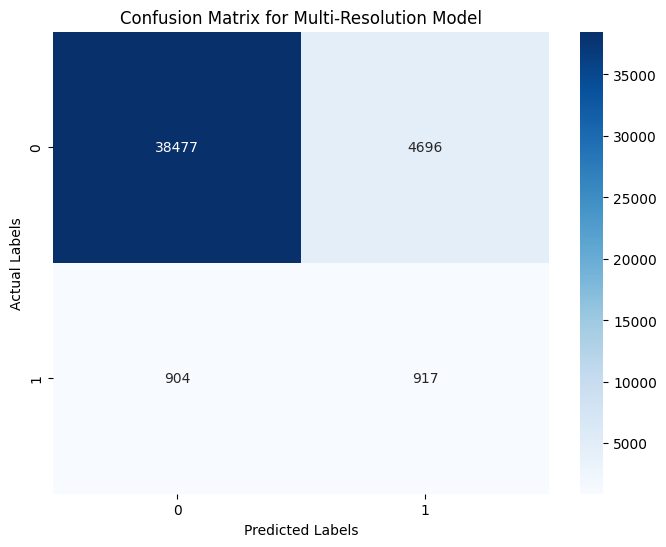

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Collect ground truth labels
y_true = []
for inputs in test_dataset:
    # The test_dataset now returns a tuple of two inputs and one target
    if len(inputs) == 3:  # If unpacked
        minute_input, hourly_input, target = inputs
    else:  # If not unpacked
        target = inputs[-1]
    y_true.extend(target.numpy())
    # Break if we've processed all the steps
    if len(y_true) >= test_steps * BATCH_SIZE:
        break

# Truncate to match the length of predictions
y_true = y_true[:len(predicted_class)]

# Create the confusion matrix
conf_matrix = confusion_matrix(y_true, predicted_class)

print("Confusion Matrix:\n", conf_matrix)

# Generate classification report
print("\nClassification Report:")
print(classification_report(y_true, predicted_class))

# Visualize the confusion matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Confusion Matrix for Multi-Resolution Model')
plt.show()

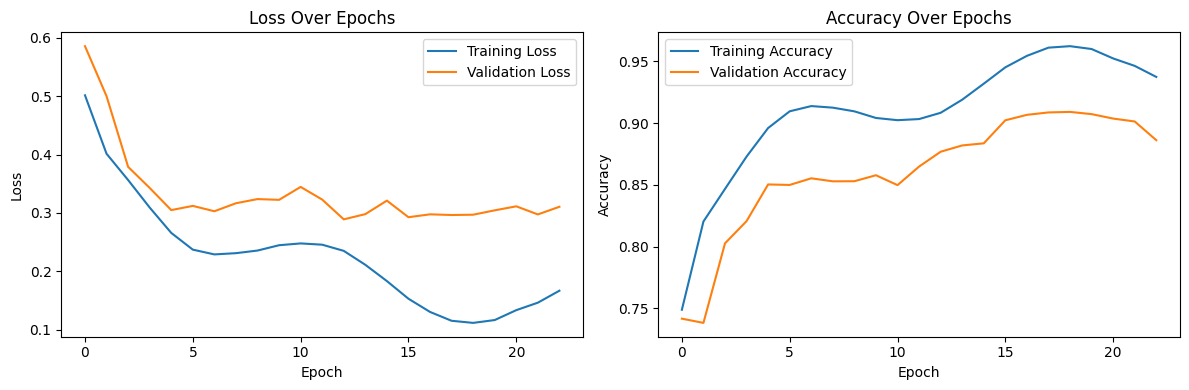

In [ ]:
# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()